[*********************100%***********************]  2 of 2 completed


📊 P-Value de co-intégration : 0.7303
⚠️ Attention : Ces deux actions ne sont pas fortement co-intégrées.


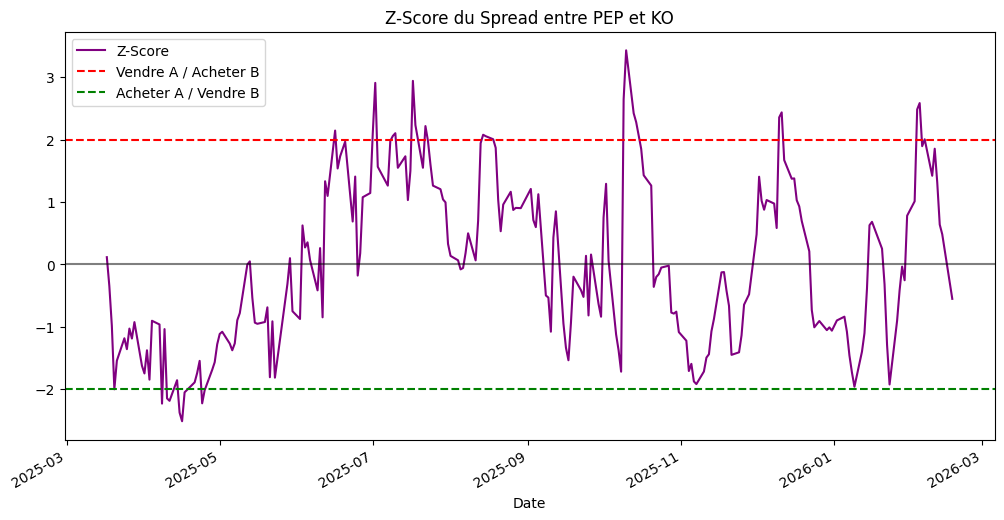

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

# --- 1. CONFIGURATION ---
TICKER_A = "PEP"  # Pepsi
TICKER_B = "KO"   # Coca-Cola
WINDOW = 20       # Moyenne mobile pour l'écart

def run_pairs_trading_scan():
    # Récupération des données
    data = yf.download([TICKER_A, TICKER_B], period="1y")['Close']
    
    # Vérification de la co-intégration
    score, pvalue, _ = coint(data[TICKER_A], data[TICKER_B])
    print(f"📊 P-Value de co-intégration : {pvalue:.4f}")
    
    if pvalue > 0.05:
        print("⚠️ Attention : Ces deux actions ne sont pas fortement co-intégrées.")

    # Calcul du Ratio (Spread)
    data['Ratio'] = data[TICKER_A] / data[TICKER_B]
    
    # Calcul du Z-Score (Nombre d'écarts-types par rapport à la moyenne)
    mean = data['Ratio'].rolling(window=WINDOW).mean()
    std = data['Ratio'].rolling(window=WINDOW).std()
    data['Z-Score'] = (data['Ratio'] - mean) / std

    # --- 2. LOGIQUE DE SIGNAL ---
    # Si Z-Score > 2 : Vendre A, Acheter B (A est trop cher par rapport à B)
    # Si Z-Score < -2 : Acheter A, Vendre B (A est trop moins cher par rapport à B)
    
    plt.figure(figsize=(12, 6))
    data['Z-Score'].plot(color='purple')
    plt.axhline(2, color='red', linestyle='--', label='Vendre A / Acheter B')
    plt.axhline(-2, color='green', linestyle='--', label='Acheter A / Vendre B')
    plt.axhline(0, color='black', alpha=0.5)
    plt.title(f"Z-Score du Spread entre {TICKER_A} et {TICKER_B}")
    plt.legend()
    plt.show()

run_pairs_trading_scan()